In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import tools.particle_swarm_optimization as pso
import tools.particle_swarm_optimization_plot as pso_plt
import tools.peristimulus_time_histogram as psth

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



Pandas(Index=('/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250528160241', '2/3a', 'exc', 0.4593144128027848, 0.4158004158004157, 0.3964608615771406, 0.39887830585505, 0.3819561959096842, 0.3360247546294058, 0.4061306386887782, 0.3892085287434124, 0.4448097471353285, 0.4641493013586036, 0.5197505197505197, 0.39887830585505, 0.4206353043562345, 0.4544795242469661, 0.490741188415607, 0.39887830585505, 0.3505294202968621), layer=0.3722864187980467, type=0.5221679640284291)


TypeError: 'float' object is not subscriptable

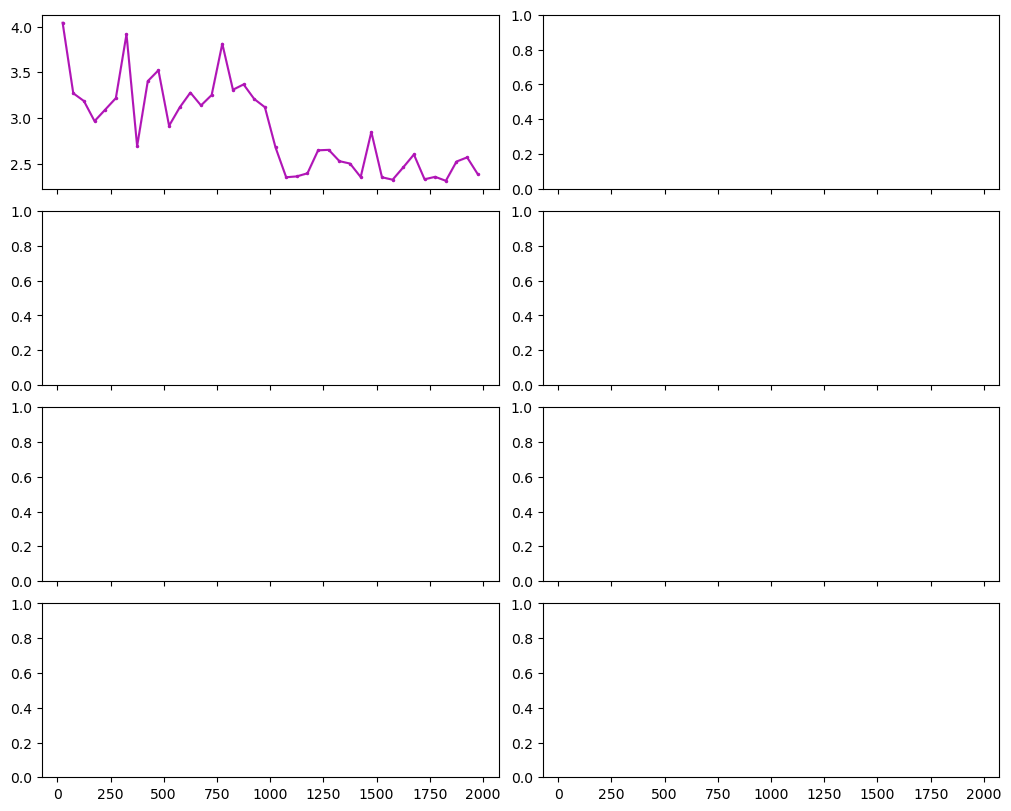

In [3]:
from scipy import stats

folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')
t_sim = 2000
l_bin = 50
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)


trial_path = os.path.join(folder_path, 'ns_04_ks_06')
ns_1_data = pd.read_csv(os.path.join(trial_path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)


a = False 
for folder in os.listdir(folder_path):
    # if a == True:
    #     continue
        
    if folder[:5] == "ns_04":
        trial_path = os.path.join(folder_path, folder)
        a = True
    else:
        continue

    hist_data = pd.read_csv(os.path.join(trial_path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)

    unique_combinations = hist_data[['layer', 'type']].drop_duplicates()

    fig, ax = plt.subplots(4,2, layout='constrained', figsize=(10,8), sharex=True)
    ax = ax.flatten()

    for j, row in enumerate(unique_combinations.itertuples()):
        print(row)
        if row.type == 'exc':
            color = '#0063B2'
        else:
            color = '#b015b6'

        subset_ns_1 = ns_1_data[(ns_1_data['type'] == row.type) & (ns_1_data['layer'] == row.layer)][names[3:]].values
        subset_ns_1 =  subset_ns_1.astype(float)

        y = np.mean(subset_ns_1,axis=0)
        ci = np.std(subset_ns_1,axis=0)#/np.sqrt(len(subset))
        ax[j].plot(bin_centers, np.mean(subset_ns_1,axis=0), '.-', color='k', markersize=2)
        ax[j].fill_between(bin_centers, (y-ci), (y+ci), color='k', alpha=.1)

        subset = hist_data[(hist_data['type'] == row.type) & (hist_data['layer'] == row.layer)][names[3:]].values
        subset = subset.astype(float)

        y = np.mean(subset,axis=0)
        ci = np.std(subset,axis=0)#/np.sqrt(len(subset))
        ax[j].plot(bin_centers, np.mean(subset,axis=0), '.-', color=color, markersize=3)
        ax[j].fill_between(bin_centers, (y-ci), (y+ci), color=color, alpha=.1)

        # T, P = [], []
        # for k in range(np.size(subset_ns_1, axis=1)):
        #     t, p = stats.ttest_ind(subset_ns_1[:,k], subset[:,k])
        #     T.append(t)
        #     P.append(p)
        #ax[j].plot(bin_centers, P, '.-', color=color, markersize=2)

        ax[j].set_title('Layer '+row.layer[0:-1]+' '+row.type, fontsize=15)
        
        if j%2==0:
            ax[j].set_ylabel('firing rate\n(spikes/s)', fontsize=15)

        if j>5:
            ax[j].set_xlabel('time [ms]', fontsize=15)

        ax[j].tick_params(axis='x', labelsize=15)
        ax[j].tick_params(axis='y', labelsize=15)

    plt.suptitle(f'K_s = {folder[10:11]}\n', fontsize=22)
    plot_name = 'psth_'+str(folder[9:11])+'_plot.png'
    plt.savefig(os.path.join(folder_path, plot_name), dpi=300) 
